# Figure 1 — Marmosets acquire deterministic visual discrimination and
# display improved performance across engagement bouts within and across
# block transitions
Source data: `_source_archive/by_figure/Fig1/04_LocationBasedShifting.ipynb`
(confirmed by user) -- panels b-d from lines 109-1086, panels e-f (ITI) from
lines 1120-1385, panels f/h/i's underlying statistics from the notebook's
own "STATS EXTRACTION: Results Section 1" section (lines 5241-5647, the
authoritative spec for the manuscript's reported numbers -- NOT the earlier
exploratory bout-analysis cells, CELL 12-16, that precede it).

Panel legends below are copied verbatim from the submitted/bioRxiv
manuscript (`2026.06.30.734629v1.full.pdf`) so each panel can be checked
directly against its own spec. Two panels (c, d) needed real rework after
cross-checking against these legends -- the source notebook's own
"trials to criterion"/"session accuracy" cells turned out to compute a
different statistic than what's actually reported (see block_learning.py
and src/plotting/fig1.py docstrings). Panels g/h/i are built directly from
the legends (no matching source-notebook plotting code exists for them).

In [1]:
import os
import sys
import json

sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
from IPython.display import SVG, display

from src.io.load_snapshots import load_config, load_snapshot
from src.behavior_metrics import block_learning as bl
from src.behavior_metrics import criterion as _criterion
from src.behavior_metrics import iti_analysis as iti
from src.behavior_metrics import reengagement as reeng
from src.plotting.style import apply_style
from src.plotting import fig1 as plotting
from src.plotting import iti as iti_plotting
from src.plotting import reengagement as reeng_plotting

config = load_config()
apply_style(config)
cfg = config["fig1"]

FIG_DIR = os.path.join("..", config["paths"]["figures_out"], "Fig1")
os.makedirs(FIG_DIR, exist_ok=True)
MANIFEST_DIR = os.path.join("..", config["paths"]["values_manifests_out"])
os.makedirs(MANIFEST_DIR, exist_ok=True)

manifest = {}


def show(path):
    display(SVG(path))

## Load data

In [2]:
df = load_snapshot(config, cfg["input_files"]["where_task_100_0"])
print(f"Loaded {len(df):,} trials from {df['Session_ID'].nunique()} sessions, "
      f"{df['Animal_Name'].nunique()} animals")
manifest["n_trials"] = int(len(df))
manifest["n_sessions"] = int(df["Session_ID"].nunique())
manifest["n_animals_raw"] = int(df["Animal_Name"].nunique())

Loaded 79,606 trials from 363 sessions, 10 animals


/Users/kevinmastro/Documents/Github/marmoset_decision_making/Final_Paper_Pipeline/src/io/load_snapshots.py:36: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


## Identify the longest block per session, filter to a qualifying subset
(used by panels b, c, d)

In [3]:
block_df = bl.summarize_blocks(df)
longest_blocks = bl.longest_block_per_session(block_df)
long_blocks_filtered, animals_included = bl.filter_long_blocks(
    longest_blocks, cfg["min_block_length"], cfg["max_block_length"], cfg["min_sessions_per_animal"]
)
print(f"Qualifying blocks: {len(long_blocks_filtered)}, animals included: {sorted(animals_included)}")
manifest["n_animals_qualifying"] = len(animals_included)
manifest["animals_qualifying"] = sorted(animals_included)
manifest["n_qualifying_blocks"] = int(len(long_blocks_filtered))

Qualifying blocks: 349, animals included: ['Coral', 'Fiona', 'Griffin', 'Knuckles', 'Raven', 'Salmon', 'Sonic', 'Sunflower', 'Tuna', 'Zazu']


## Panel a
**Manuscript legend:** *"Schematic representation of task structure.
Marmosets must select one of the two visually and spatially distinct
choices by touching a touchscreen. Depending on the choice and task
contingencies a juice reward is delivered via a spout. In the visual
discrimination task, the probability of reward for selecting one object
(the correct choice) is 1 and 0 for other object (the incorrect choice).
The identity and location of the rewarded visual object are held constant
for a variable length of trials (a block) before changing."*

**Status: not applicable.** This is a task-schematic illustration, not a
data-derived panel -- no analysis to run.

## Panel b
**Manuscript legend:** *"Probability of selecting the rewarded choice
('accuracy') at each trial position on average (black with shaded grey
standard error of the mean) and for individual marmosets (colored
lines)."*

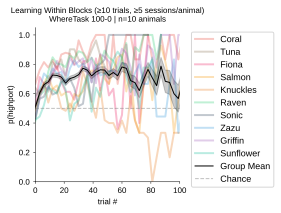

In [4]:
learning_df, binned_learning, overall_learning = bl.within_block_learning_curve(
    df, long_blocks_filtered, cfg["trial_bin_size"]
)
plotting.plot_within_block_learning(binned_learning, overall_learning, config,
                                      os.path.join(FIG_DIR, "within_block_learning.svg"))
show(os.path.join(FIG_DIR, "within_block_learning.svg"))
manifest["within_block_learning_first_bin_accuracy"] = float(overall_learning.iloc[0]["accuracy"])
manifest["within_block_learning_last_bin_accuracy"] = float(overall_learning.iloc[-1]["accuracy"])

## Panel c
**Manuscript legend:** *"Trials to criterion (top, accuracy >= 0.8 across
5 trials) and the accuracy in the final 10 trials of a block (bottom,
'late accuracy') across all individual marmosets (bars) and sessions
(dots)."*

Rebuilt from this legend (see `block_learning.py::trials_to_criterion_rolling`
docstring): the source notebook's own CELL 5-8 turned out to implement a
different, unrelated statistic (a "5 consecutive correct trials" rule, a
20-trial late window, block-level not session-level dots) -- found by
cross-checking against this exact legend text.

Sessions reaching criterion: 318/349 (91.1%), mean trials to criterion: 8.8
Late accuracy (final 10 trials): 0.749 +/- 0.014


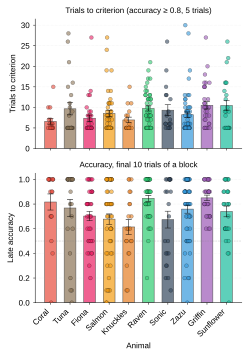

In [5]:
ttc_raw = bl.trials_to_criterion_rolling(
    df, long_blocks_filtered, cfg["criterion_accuracy"], cfg["criterion_window"]
)
ttc_df = _criterion.clean_ttc(ttc_raw)
print(f"Sessions reaching criterion: {len(ttc_df)}/{len(ttc_raw)} "
      f"({len(ttc_df) / len(ttc_raw) * 100:.1f}%), mean trials to criterion: {ttc_df['trials_to_criterion'].mean():.1f}")

late_acc_df = bl.asymptotic_performance(df, long_blocks_filtered, cfg["late_accuracy_window"])
print(f"Late accuracy (final {cfg['late_accuracy_window']} trials): "
      f"{late_acc_df['asymptote_accuracy'].mean():.3f} +/- {late_acc_df['asymptote_accuracy'].sem():.3f}")

plotting.plot_trials_to_criterion_and_late_accuracy(
    ttc_df, late_acc_df, config, os.path.join(FIG_DIR, "trials_to_criterion.svg")
)
show(os.path.join(FIG_DIR, "trials_to_criterion.svg"))

ttc_per_animal = ttc_df.groupby("animal")["trials_to_criterion"].mean()
late_per_animal = late_acc_df.groupby("animal")["asymptote_accuracy"].mean()
manifest["trials_to_criterion"] = {
    "n_sessions_total": int(len(ttc_raw)), "n_reached": int(len(ttc_df)),
    "pct_reached": float(len(ttc_df) / len(ttc_raw) * 100),
    "mean": float(ttc_df["trials_to_criterion"].mean()),
    "sem": float(ttc_df["trials_to_criterion"].sem()),
    "n_animals": int(ttc_per_animal.shape[0]),
    "mean_per_animal": float(ttc_per_animal.mean()),
    "sem_per_animal": float(ttc_per_animal.sem()),
}
manifest["late_accuracy"] = {
    "n_sessions": int(len(late_acc_df)),
    "mean": float(late_acc_df["asymptote_accuracy"].mean()),
    "sem": float(late_acc_df["asymptote_accuracy"].sem()),
    "n_animals": int(late_per_animal.shape[0]),
    "mean_per_animal": float(late_per_animal.mean()),
    "sem_per_animal": float(late_per_animal.sem()),
}

## Panel d
**Manuscript legend:** *"Accuracy of selecting the rewarded choice over
the course of 10 sessions. Individual dots represent a marmoset's
performance per session (bin size = 5), and the colored lines correspond
to the performance averaged across multiple days. Dashed line indicates
chance (0.5)"*

Rebuilt from this legend: the previous version of this panel was a 2-box
boxplot (sessions 0-4 vs. 5-9) -- correct statistic, wrong visualization.
Now a per-session scatter with a per-animal binned (bin size=5) trend
line, matching the legend. The reported statistic itself (accuracy after
~10 sessions vs. chance) is unchanged.

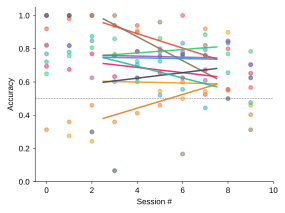

{'bin0_mean': np.float64(0.7246507612849945), 'bin0_sem': np.float64(0.03275057590892238), 'bin0_n': 50, 'bin1_mean': np.float64(0.6712588094110988), 'bin1_sem': np.float64(0.024644660343997725), 'bin1_n': 50, 'bin1_per_animal_mean': np.float64(0.6712588094110988), 'bin1_per_animal_sem': np.float64(0.026211960224475715), 'n_animals': 10, 'mannwhitney_p_bin0_vs_bin1': np.float64(0.06556923132623889), 'wilcoxon_p_bin1_vs_chance_per_animal': np.float64(0.001953125)}


In [6]:
all_sessions_df = bl.session_accuracy_trajectory(df, long_blocks_filtered)
session_bin_stats = plotting.plot_session_bins(
    all_sessions_df, cfg["session_bin_size"], config, os.path.join(FIG_DIR, "session_bins.svg")
)
show(os.path.join(FIG_DIR, "session_bins.svg"))
print(session_bin_stats)
manifest["session_bins"] = {k: float(v) for k, v in session_bin_stats.items()}

A separate, secondary "asymptotic accuracy" statistic (trailing-20-trial
window, not tied to a specific lettered panel) is also computed here for
completeness, since block_learning.py's `asymptotic_performance` is
already available and this stat was tracked in earlier verification
passes.

In [7]:
asymptote_df = bl.asymptotic_performance(df, long_blocks_filtered, cfg["asymptote_window"])
print(f"Overall asymptotic accuracy (20-trial window): {asymptote_df['asymptote_accuracy'].mean():.3f}")
manifest["asymptotic_accuracy_overall_mean"] = float(asymptote_df["asymptote_accuracy"].mean())
manifest["asymptotic_accuracy_overall_sem"] = float(asymptote_df["asymptote_accuracy"].sem())

Overall asymptotic accuracy (20-trial window): 0.740


## Inter-trial interval (ITI) data prep
Feeds panels e and f. Ported from CELL 11 of the source notebook (lines
1120-1385). An earlier, abandoned ITI calculation (lines 935-951, using a
nonsensical MAX_ITI left over from a draft) is not ported -- CELL 11 is
the version actually used to generate this notebook's saved figure.

In [8]:
df_timing = iti.compute_iti(df)
df_timing_filtered = iti.filter_iti(df_timing, cfg["max_iti"])
print(f"ITI statistics (n={len(df_timing_filtered):,} trials after filtering to <= {cfg['max_iti']}s):")
print(f"  Mean: {df_timing_filtered['ITI'].mean():.2f}s, Median: {df_timing_filtered['ITI'].median():.2f}s, "
      f"Std: {df_timing_filtered['ITI'].std():.2f}s")
manifest["iti"] = {
    "n_trials": int(len(df_timing_filtered)),
    "mean": float(df_timing_filtered["ITI"].mean()),
    "median": float(df_timing_filtered["ITI"].median()),
    "std": float(df_timing_filtered["ITI"].std()),
}

ITI statistics (n=79,118 trials after filtering to <= 1000s):
  Mean: 13.20s, Median: 4.83s, Std: 50.72s


## Panel e
**Manuscript legend:** *"ITI probability distributions for each marmoset.
Medians are marked by the vertical lines."*

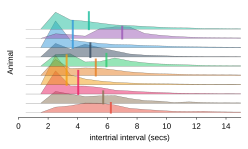

      animal  median_iti   mean_iti    std_iti
0      Coral    6.232620  22.712778  67.782215
1       Tuna    5.716557  27.755193  92.994820
2      Fiona    4.032850   9.531618  40.912001
3     Salmon    3.249446  15.695596  67.216638
4   Knuckles    5.216656  11.548691  32.073977
5      Raven    5.932657  13.952739  56.672648
6      Sonic    4.849811  15.520177  56.291068
7       Zazu    3.666273  10.970969  44.838876
8    Griffin    6.999210  13.404600  36.433328
9  Sunflower    4.749499  14.476235  53.968077


In [9]:
iti_plotting.plot_iti_ridge(df_timing_filtered, config, os.path.join(FIG_DIR, "iti_ridge.svg"))
show(os.path.join(FIG_DIR, "iti_ridge.svg"))
iti_summary_df = iti.iti_summary_by_animal(df_timing_filtered, config["plotting"]["animal_order"])
print(iti_summary_df)
manifest["iti_by_animal"] = iti_summary_df.set_index("animal").to_dict(orient="index")

## Panel f
**Manuscript legend:** *"Average accuracy for trials binned by the
previous ITI for individual animals (colored lines) and aggregated
across animals (grey bar plots)."*

The manuscript text also quotes a specific disengagement statistic tied
to this panel ("ITI > 60 seconds ... accuracy=0.604+/-0.010 ... Figure
1f") -- this is the same quantity as the last (">60s") bin below, just
computed independently here (per-animal Wilcoxon vs. chance) as a
cross-check, not a separate lettered panel.

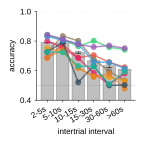

  ITI_bin  accuracy       sem      n
0    2-5s  0.789682  0.002054  39369
1   5-10s  0.786789  0.002484  27189
2  10-15s  0.721038  0.006243   5162
3  15-30s  0.667654  0.008108   3376
4  30-60s  0.632538  0.012087   1592
5    >60s  0.609053  0.009901   2430


In [10]:
iti_performance = iti.performance_by_iti_bin(df_timing_filtered, cfg["iti_bins"], cfg["iti_labels"])
animal_iti_performance = iti.performance_by_iti_bin_by_animal(df_timing_filtered, cfg["iti_bins"], cfg["iti_labels"])
iti_plotting.plot_iti_performance(iti_performance, animal_iti_performance, config, os.path.join(FIG_DIR, "iti_performance.svg"))
show(os.path.join(FIG_DIR, "iti_performance.svg"))
print(iti_performance)
manifest["performance_by_iti_bin"] = {
    str(row["ITI_bin"]): {"accuracy": float(row["accuracy"]), "sem": float(row["sem"]), "n": int(row["n"])}
    for _, row in iti_performance.iterrows()
}

In [11]:
disengage_result = reeng.disengagement_accuracy(df, cfg["disengagement_iti_threshold"])
print(f"Cross-check -- accuracy after ITI > {cfg['disengagement_iti_threshold']}s: "
      f"{disengage_result['mean']:.3f} +/- {disengage_result['sem']:.3f} "
      f"(n={disengage_result['n_trials']} trials, {disengage_result['n_animals']} animals), "
      f"Wilcoxon vs chance p={disengage_result['wilcoxon_p_vs_chance_per_animal']:.4e} "
      f"-- manuscript text: 0.604+/-0.010, p=0.012")
manifest["disengagement_accuracy_crosscheck"] = disengage_result

Cross-check -- accuracy after ITI > 60s: 0.604 +/- 0.010 (n=2555 trials, 10 animals), Wilcoxon vs chance p=1.1719e-02 -- manuscript text: 0.604+/-0.010, p=0.012


ITI is also examined via a long-break (>=25s) split, as a secondary
robustness check alongside the binned version above (not itself a
separate lettered panel).

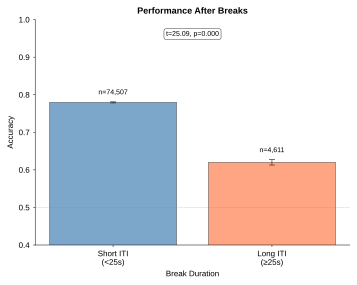

Trial-level: t=25.09, p=2.043e-138
Per-animal (n=10): short=0.762, long=0.601, Wilcoxon p=0.0020


In [12]:
break_result = iti.performance_by_long_break(df_timing_filtered, cfg["long_break_threshold"])
iti_plotting.plot_long_break_performance(break_result, cfg["long_break_threshold"], config,
                                           os.path.join(FIG_DIR, "long_break_performance.svg"))
show(os.path.join(FIG_DIR, "long_break_performance.svg"))
print(f"Trial-level: t={break_result['t_stat_trial_level']:.2f}, p={break_result['p_trial_level']:.3e}")
print(f"Per-animal (n={break_result['n_animals_paired']}): "
      f"short={break_result['per_animal_short_mean']:.3f}, long={break_result['per_animal_long_mean']:.3f}, "
      f"Wilcoxon p={break_result['p_per_animal']:.4f}")
manifest["long_break"] = {
    "threshold_s": cfg["long_break_threshold"],
    "trial_level_t_stat": float(break_result["t_stat_trial_level"]),
    "trial_level_p": float(break_result["p_trial_level"]),
    "n_animals_paired": break_result["n_animals_paired"],
    "per_animal_short_mean": float(break_result["per_animal_short_mean"]),
    "per_animal_long_mean": float(break_result["per_animal_long_mean"]),
    "per_animal_wilcoxon_p": float(break_result["p_per_animal"]),
}

## Panel g
**Manuscript legend:** *"Representative session showing blocks, bouts,
ITIs and performance across one session. Blocks are predefined changes in
the visual discrimination rule. Bouts are a series of trials with a
maximum ITI of 15 seconds (red vertical dashed line, average 8.8+/-5.0
bouts per session). Performance is given by the accuracy of selecting the
rewarding choice over a 5-trial sliding window."*

Built directly from this legend -- no source-notebook plotting cell
matches it. The example session is picked as the one with the most
blocks (a documented judgment call; the source doesn't state a selection
rule).

Bouts per session: 27.9 +/- 13.6 (n=363 sessions) -- manuscript text: 8.8+/-5.0
Panel g example session: 2021-08-25_20210825_Griffin_100%Con_WhereBlocks(1) (44 trials)


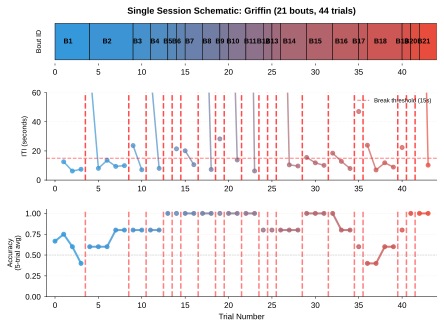

In [13]:
bouts_stat = reeng.bouts_per_session(df, cfg["bout_iti_threshold"])
print(f"Bouts per session: {bouts_stat['mean']:.1f} +/- {bouts_stat['std']:.1f} "
      f"(n={bouts_stat['n_sessions']} sessions) -- manuscript text: 8.8+/-5.0")
manifest["bouts_per_session"] = bouts_stat

session_trace, example_session_id = reeng.representative_session_trace(
    df, cfg["bout_iti_threshold"], cfg["representative_session_rolling_window"]
)
print(f"Panel g example session: {example_session_id} ({len(session_trace)} trials)")
reeng_plotting.plot_representative_session(
    session_trace, cfg["bout_iti_threshold"], config, os.path.join(FIG_DIR, "representative_session.svg")
)
show(os.path.join(FIG_DIR, "representative_session.svg"))
manifest["representative_session_id"] = example_session_id

## Panel h
**Manuscript legend:** *"Re-engagement within block. Within each bout,
line plots show the performance across the first 15 trials (left)
followed by bar plots of the aggregate performance at the start and end
of the first three bouts (middle) and boxplots of the bout lengths for
each bout (right). Bouts shorter than 15 trials contribute all available
trials."*

The bar/boxplot statistics (start-vs-end accuracy, bout length by rank)
are the source notebook's own "STATS EXTRACTION" STAT 5/6 (lines
5406-5489) -- the line-plot sub-panel is built directly from the legend,
since no source cell plots it.

Within-block bouts identified: 7671
   bout_rank  n_bouts  n_animals  start_mean  start_sem  end_mean   end_sem  \
0          1      363         10    0.566838   0.026810  0.571024  0.027398   
1          2      363         10    0.627891   0.025057  0.677567  0.033444   
2          3      358         10    0.661605   0.026831  0.687584  0.037955   

   wilcoxon_p  
0    0.250000  
1    0.109375  
2    0.375000  
Bout length by rank: [2.0358126721763083, 12.275482093663912, 10.150837988826815], Kruskal-Wallis p=1.7015e-52


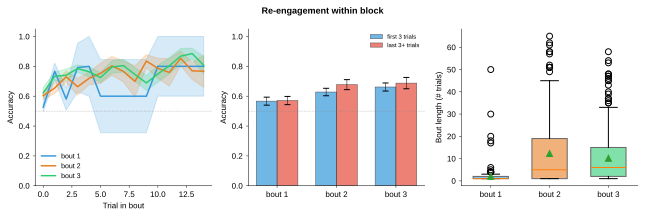

In [14]:
wb_df = reeng.within_block_bouts(df, cfg["bout_iti_threshold"], cfg["bout_start_end_window"])
print(f"Within-block bouts identified: {len(wb_df)}")
start_end_df = reeng.start_vs_end_accuracy_by_rank(wb_df, cfg["bout_ranks_to_compare"])
print(start_end_df)
manifest["bout_start_vs_end"] = start_end_df.to_dict(orient="records")

bout_length_result = reeng.bout_length_kruskal(wb_df, cfg["bout_ranks_to_compare"])
print(f"Bout length by rank: {bout_length_result['means']}, Kruskal-Wallis p={bout_length_result['p_value']:.4e}")
manifest["bout_length_kruskal"] = bout_length_result

position_df_h = reeng.bout_position_accuracy(
    df, cfg["bout_iti_threshold"], "within_block", cfg["bout_ranks_to_compare"], cfg["reengagement_line_max_trials"]
)
reeng_plotting.plot_reengagement_composite(
    position_df_h, start_end_df, wb_df, cfg["bout_ranks_to_compare"],
    "Re-engagement within block", config, os.path.join(FIG_DIR, "reengagement_within_block.svg"),
)
show(os.path.join(FIG_DIR, "reengagement_within_block.svg"))

## Panel i
**Manuscript legend:** *"Re-engagement across block transitions. Within
each bout, line plots show the performance across the first 15 trials
(left) followed by bar plots of the aggregate performance at the start
and end of each bout (middle) and boxplots of the bout lengths for each
bout (right). Bouts shorter than 15 trials contribute all available
trials."*

Same 3-part layout as panel h, applied to bouts that start at a block
transition instead of within-block bouts. The headline "trials to
re-engagement" statistic is STAT 7 (lines 5496-5530).

Trials to re-engagement: 5.32 +/- 0.06 (63.9% reach criterion, n=2460 bouts, 10 animals)


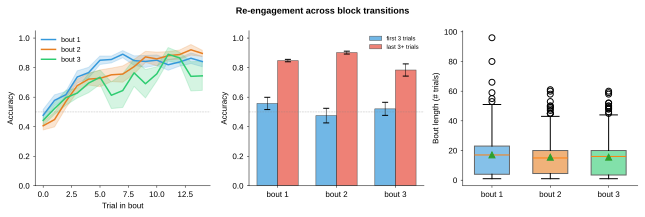

In [15]:
bt_df = reeng.block_transition_bouts(df, cfg["bout_iti_threshold"],
                                       cfg["reengagement_criterion_accuracy"], cfg["reengagement_criterion_window"])
reengagement_result = reeng.reengagement_summary(bt_df)
print(f"Trials to re-engagement: {reengagement_result['mean_trials_to_criterion']:.2f} +/- "
      f"{reengagement_result['sem_trials_to_criterion']:.2f} "
      f"({reengagement_result['frac_reached_criterion']*100:.1f}% reach criterion, "
      f"n={reengagement_result['n_bouts_total']} bouts, {reengagement_result['n_animals']} animals)")
manifest["reengagement"] = reengagement_result

# Re-derive start/end accuracy for block-transition bouts directly (bt_df's
# own columns don't include start/end window accuracy the same way wb_df
# does -- build it from the position trace instead, at the same window
# used for panel h, for a like-for-like bar/box panel).
position_df_i = reeng.bout_position_accuracy(
    df, cfg["bout_iti_threshold"], "block_transition", cfg["bout_ranks_to_compare"], cfg["reengagement_line_max_trials"]
)
_w = cfg["bout_start_end_window"]
start_end_records = []
for rank in cfg["bout_ranks_to_compare"]:
    d_rank = position_df_i[position_df_i["bout_rank"] == rank]
    start_end_records.append({
        "bout_rank": rank,
        "start_mean": d_rank[d_rank["trial_in_bout"] < _w]["mean"].mean(),
        "start_sem": d_rank[d_rank["trial_in_bout"] < _w]["mean"].sem(),
        "end_mean": d_rank[d_rank["trial_in_bout"] >= cfg["reengagement_line_max_trials"] - _w]["mean"].mean(),
        "end_sem": d_rank[d_rank["trial_in_bout"] >= cfg["reengagement_line_max_trials"] - _w]["mean"].sem(),
    })
start_end_df_i = pd.DataFrame(start_end_records)

reeng_plotting.plot_reengagement_composite(
    position_df_i, start_end_df_i, bt_df, cfg["bout_ranks_to_compare"],
    "Re-engagement across block transitions", config, os.path.join(FIG_DIR, "reengagement_across_transitions.svg"),
)
show(os.path.join(FIG_DIR, "reengagement_across_transitions.svg"))

## Values manifest

In [16]:
manifest_path = os.path.join(MANIFEST_DIR, "Fig1.json")
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2, default=str)
print(f"\nSaved values manifest: {manifest_path}")


Saved values manifest: ../outputs/values_manifests/Fig1.json
